In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_1.jsonl",
    lines=True
)

print(df.shape)
df.head()

(158158, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,2ef9a92ee6c955364564b0df75ee3753473014b2ba162b...,7e39aeea7bc21d16b8652516a150b282,2018-01,1,sivis,"[60782, 5895, 2020, 1487, 2075, 1367, 1145, 85...","[24434, 11, 18, 5, 9, 8, 35, 21, 3, 4, 8, 4, 2...","{'numstrings': 3863, 'avlength': 17.6435412891...","{'size': 349811, 'vsize': 28672, 'has_debug': ...","{'coff': {'timestamp': 1301832471, 'machine': ...","{'entry': '.code', 'sections': [{'name': '.cod...","{'MSVCRT.dll': ['memset', 'memcpy', '_stricmp'...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,50f3f85a10cedf9192f7aa4cd4d2b1ce9e294e23f3dd7e...,09435239e7a0ddfeb78820cf5c31cc06,2018-01,-1,upatre,"[11971, 74, 27, 147, 61, 61, 19, 27, 53, 34, 1...","[2006, 2, 3, 0, 4, 3, 3, 1, 9, 1, 3, 0, 1, 2, ...","{'numstrings': 82, 'avlength': 11.097560975609...","{'size': 33776, 'vsize': 36864, 'has_debug': 0...","{'coff': {'timestamp': 1401281511, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'kernel32.dll': ['Sleep', 'VirtualAlloc', 'Si...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
2,f6c68207b3b395feabcbb029c393607db4ff5227ecd5da...,744cac35cdfa2c3a0672184d433cb93e,2018-01,0,,"[35534, 3516, 1832, 870, 957, 596, 435, 501, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1452, 'avlength': 15.4869146005...","{'size': 161280, 'vsize': 184320, 'has_debug':...","{'coff': {'timestamp': 1512336134, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WrldFlsh.exe': ['pszStatName', 'dbWeather1',...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
3,3292ee48fac44b7b70bdfde526f71c09e65764d9b582f5...,b6d6f2dc5ef191e23dfc2892ff626168,2018-01,0,,"[3389, 100, 35, 9, 18, 7, 16, 12, 12, 7, 28, 6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 65, 'avlength': 20.030769230769...","{'size': 6144, 'vsize': 32768, 'has_debug': 0,...","{'coff': {'timestamp': 1499089577, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorExeMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,b9494c218b74a9774a88307ba83c03da0bee3a80899b47...,b6607d4123b0d3afdbca4bdc9a4bcf7a,2018-01,-1,startsurf,"[256325, 3576, 3209, 3073, 3900, 2695, 2711, 2...","[329804, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","{'numstrings': 5970, 'avlength': 23.8986599664...","{'size': 1242112, 'vsize': 1265664, 'has_debug...","{'coff': {'timestamp': 1515165337, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['CreateEventA', 'CloseHandle...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [3]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
158153,cb95c231190f09dbdffbac5cfd1fd49e9316ead23922d3...,599a5d42054afa5374906fda891d1154,2018-02,-1,,"[182440, 6562, 2597, 2887, 3014, 2056, 1797, 1...","[4078, 28, 6, 6, 13, 5, 9, 3, 6, 6, 0, 3, 6, 3...","{'numstrings': 1420, 'avlength': 11.6457746478...","{'size': 553240, 'vsize': 335872, 'has_debug':...","{'coff': {'timestamp': 1195662329, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['SetFileTime', 'CompareFileT...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
158154,979a7372fbec8df171c9dc8316f5a5c1103344e40d6274...,bf81903133d27c78e4af85ea841f56fa,2018-02,0,,"[74412, 1967, 1790, 3794, 1532, 676, 687, 481,...","[18432, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 1592, 'avlength': 7.32474874371...","{'size': 479232, 'vsize': 483328, 'has_debug':...","{'coff': {'timestamp': 1168517843, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'MSVBVM60.DLL': ['EVENT_SINK_GetIDsOfNames', ...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
158155,c60af4f791e7a751df5f1f14eeca498bd5dafac7fec89c...,24ab26c42710db8ae8e92a1757f0f921,2018-02,0,,"[314531, 30012, 16687, 19383, 27034, 16551, 72...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 11528, 'avlength': 16.844465648...","{'size': 2056192, 'vsize': 2166784, 'has_debug...","{'coff': {'timestamp': 1518077831, 'machine': ...","{'entry': '.code', 'sections': [{'name': '.cod...","{'MSVCRT.dll': ['memset', 'sprintf', 'wcslen',...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
158156,873b54e5d6824ff15d8f144edef91e9dee35c1d8bf003f...,a397748ef124462db9db187c975c490a,2018-02,-1,,"[293907, 68496, 11683, 6992, 10210, 5459, 2799...","[26582, 5, 3, 3, 10207, 6, 2, 2, 0, 3, 0, 2, 3...","{'numstrings': 2922, 'avlength': 14.2498288843...","{'size': 1191424, 'vsize': 1220608, 'has_debug...","{'coff': {'timestamp': 1465583470, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WSOCK32.dll': ['ordinal116', 'ordinal23', 'o...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
158157,1272b356b92acecf21dc5c7dd7434bd296b768d31c03fe...,e4ebe7942f8ff695466d4a825476f330,2018-02,1,prepscram,"[162080, 2694, 2471, 2351, 2666, 2229, 2196, 2...","[237565, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0...","{'numstrings': 2797, 'avlength': 6.92920986771...","{'size': 746496, 'vsize': 765952, 'has_debug':...","{'coff': {'timestamp': 1518872360, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['VirtualProtect', 'GetModule...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158158 entries, 0 to 158157
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   sha256           158158 non-null  str   
 1   md5              158158 non-null  str   
 2   appeared         158158 non-null  str   
 3   label            158158 non-null  int64 
 4   avclass          158158 non-null  str   
 5   histogram        158158 non-null  object
 6   byteentropy      158158 non-null  object
 7   strings          158158 non-null  object
 8   general          158158 non-null  object
 9   header           158158 non-null  object
 10  section          158158 non-null  object
 11  imports          158158 non-null  object
 12  exports          158158 non-null  object
 13  datadirectories  158158 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 16.9+ MB


In [5]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [7]:
print(df["label"].value_counts())

label
 1    63713
 0    52338
-1    42107
Name: count, dtype: int64


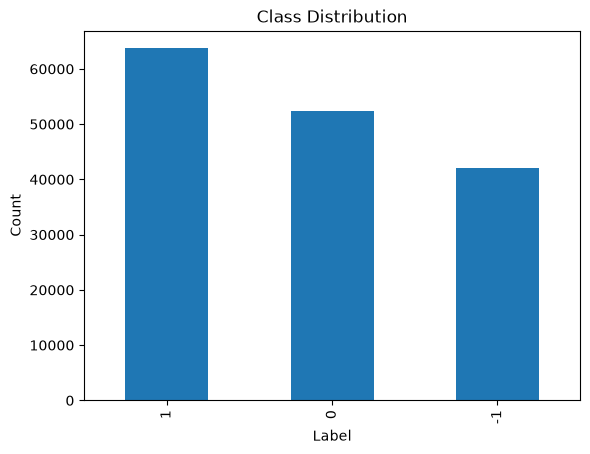

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [9]:
df.describe()

,label
count,158158.000000
mean,0.136610
std,0.806486
min,-1.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

971.0885400772095 MB


In [11]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [12]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [13]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [14]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_1"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_1_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
